In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional for time series
import datetime as dt

In [29]:
inflation = pd.read_excel("data/kz_inflation_from_2016_to_2026.xlsx")
oil = pd.read_excel("data/oil_from_2015_to_2026.xlsx")
fx = pd.read_excel("data/usdkzt_from_2016_to_2026.xlsx")

In [30]:
# inflation.head()
# oil.head()
# fx.head()

def clean_bloomberg(df, value_name):
    df = df.copy()    
    df.columns = ["Date", value_name]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    return df

inflation = clean_bloomberg(inflation, "inflation")
# oil = clean_bloomberg(oil, "oil_price")
fx = clean_bloomberg(fx, "usdkzt")

In [31]:
oil = oil.copy()
oil["Date"] = pd.to_datetime(oil["Date"])
oil = oil[["Date", "Last Price"]]
oil = oil.rename(columns={"Last Price": "oil_price"})
oil = oil.sort_values("Date")
# oil.head()

In [32]:
df = inflation.merge(oil, on="Date", how="inner")
df = df.merge(fx, on="Date", how="inner")

df.head()

,Date,inflation,oil_price,usdkzt
0,2016-03-31,15.7,39.60,344.59
1,2016-05-31,16.7,49.69,336.10
2,2016-06-30,17.3,49.68,339.18
3,2016-08-31,17.6,47.04,340.50
4,2016-09-30,16.6,49.06,335.84


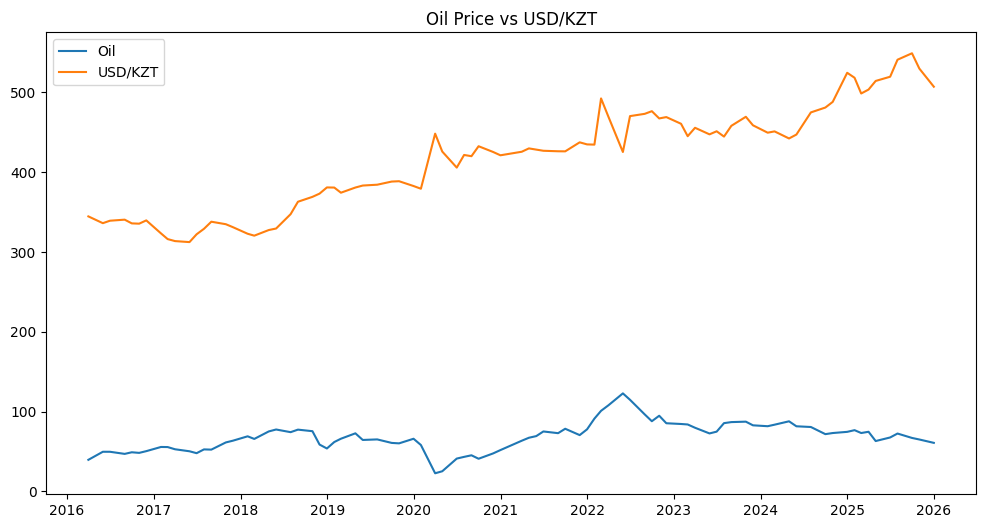

In [33]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["oil_price"], label="Oil")
plt.plot(df["Date"], df["usdkzt"], label="USD/KZT")
plt.legend()
plt.title("Oil Price vs USD/KZT")
plt.show()

- Oil: volatile (big drop in 2020, spike in 2022)
- USD/KZT: clear upward trend (tenge weakening)

-> Even when oil recovers, KZT does not fully strengthen back

In [34]:
df[["inflation", "oil_price", "usdkzt"]].corr()

,inflation,oil_price,usdkzt
inflation,1.000000,0.325421,0.319184
oil_price,0.325421,1.000000,0.438853
usdkzt,0.319184,0.438853,1.000000


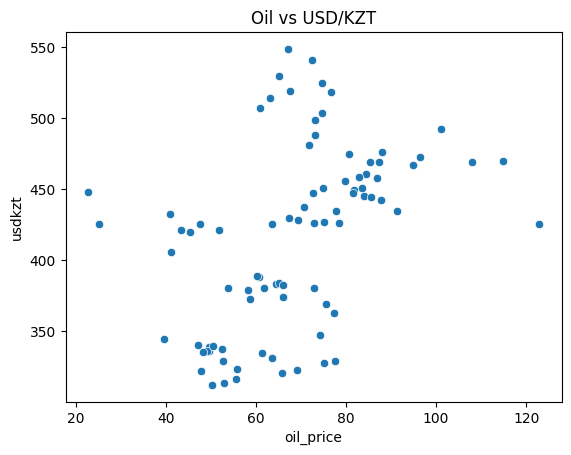

In [35]:
sns.scatterplot(data=df, x="oil_price", y="usdkzt")
plt.title("Oil vs USD/KZT")
plt.show()

We assume that Higher oil -> stronger KZT -> lower USD/KZT.

But in reality got weak / noisy positive relationship

In [36]:
df["oil_return"] = df["oil_price"].pct_change()
df["fx_return"] = df["usdkzt"].pct_change()
df["inflation_change"] = df["inflation"].diff()

In [37]:
df["oil_lag1"] = df["oil_price"].shift(1)
df["oil_lag3"] = df["oil_price"].shift(3)

In [38]:
import statsmodels.api as sm

X = df[["oil_price"]].dropna()
y = df.loc[X.index, "usdkzt"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 usdkzt   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     19.80
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.65e-05
Time:                        19:30:00   Log-Likelihood:                -464.53
No. Observations:                  85   AIC:                             933.1
Df Residuals:                      83   BIC:                             937.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        309.8648     24.795     12.497      0.0

In [39]:
df["oil_return"] = df["oil_price"].pct_change()
df["fx_return"] = df["usdkzt"].pct_change()

df = df.dropna()


import statsmodels.api as sm

X = df[["oil_return"]]
y = df["fx_return"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_return   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     19.54
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.06e-05
Time:                        19:30:00   Log-Likelihood:                 161.70
No. Observations:                  82   AIC:                            -319.4
Df Residuals:                      80   BIC:                            -314.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0071      0.004      1.885      0.0

Oil ↑ → USD/KZT ↓
- Transforming data into returns revealed the true inverse relationship between oil prices and the Kazakh tenge.
- Changes in oil prices have a statistically significant negative effect on exchange rate movements. [Coefficient: -0.129; p-value: < 0.001]
- Oil explains about 20% of exchange rate fluctuations, indicating that while important, it is not the sole driver of currency movements.
- Using returns eliminates spurious regression and produces a statistically reliable model. [Durbin-Watson: ~2.14, no strong autocorrelation]

The question is what explains other 80%?

The Kazakh tenge is partially oil-driven, but the relationship is not strong enough to fully explain exchange rate movements. Oil shocks do impact FX, but other macroeconomic and policy factors play a significant role.

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(df[["fx_return", "oil_return"]], maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3858  , p=0.5363  , df_denom=78, df_num=1
ssr based chi2 test:   chi2=0.4007  , p=0.5267  , df=1
likelihood ratio test: chi2=0.3997  , p=0.5272  , df=1
parameter F test:         F=0.3858  , p=0.5363  , df_denom=78, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0229  , p=0.9774  , df_denom=75, df_num=2
ssr based chi2 test:   chi2=0.0488  , p=0.9759  , df=2
likelihood ratio test: chi2=0.0487  , p=0.9759  , df=2
parameter F test:         F=0.0229  , p=0.9774  , df_denom=75, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0095  , p=0.9987  , df_denom=72, df_num=3
ssr based chi2 test:   chi2=0.0313  , p=0.9985  , df=3
likelihood ratio test: chi2=0.0313  , p=0.9985  , df=3
parameter F test:         F=0.0095  , p=0.9987  , df_denom=72, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.3858498798451838),
    np.float64(0.5363000983243634),
    np.float64(78.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.40069025983922935),
    np.float64(0.5267329931361995),
    np.int64(1)),
   'lrtest': (np.float64(0.39970245020731454),
    np.float64(0.5272429639631133),
    np.int64(1)),
   'params_ftest': (np.float64(0.38584987984519076),
    np.float64(0.5363000983243595),
    np.float64(78.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.022855043503570826),
    np.float64(0.9774109591792784),
    np.float64(75.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.04875742614095109),
    np.float64(0.9759160476014689),
    np.int64(2)),
   'lrtest': (np.float64(0.048742574133825656),
    np.float64(0.975923294784424),
    np.int64(2)),
   'params_ftest': (np.float64(0.0228550435035678),
    np.float64(0.9774109591792814),
    np.float64(75.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
   

It means oil and KZT move together contemporaneously (as we found before through OLS), but oil prices don't help predict next month's KZT move. This suggests the FX market prices in oil shocks almost immediately - the tenge is reactive, not lagging.

<Axes: title={'center': 'Rolling Oil Beta on KZT'}>

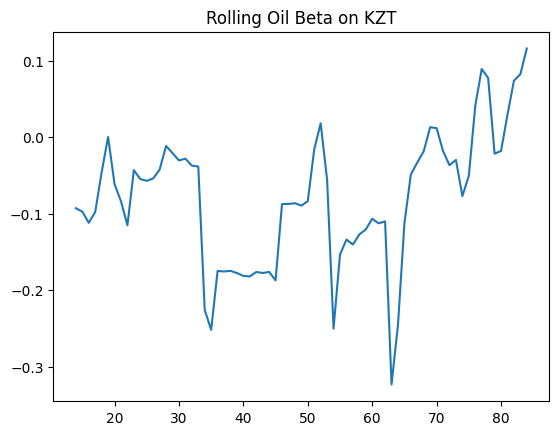

In [41]:
from statsmodels.regression.rolling import RollingOLS
rolling_model = RollingOLS(df["fx_return"], sm.add_constant(df["oil_return"]), window=12).fit()
rolling_model.params["oil_return"].plot(title="Rolling Oil Beta on KZT")

The x-axis is observation index (months), so roughly: index 10–30 ≈ 2016–2018, 30–50 ≈ 2019–2021, 50–70 ≈ 2022–2023, 70–85 ≈ 2024–2025.

The story this tells is striking:
- 2016–2019: beta consistently negative (−0.05 to −0.2), oil-KZT relationship working as expected
- Around index 35 (2019–2020): beta spikes to −0.25, the COVID oil crash hit KZT hard — strongest oil sensitivity in the sample
- Index 60–65 (mid-2022): beta crashes to −0.33, the Russia invasion period — oil spiked but KZT also came under massive pressure from Russia spillovers, making the negative relationship look extreme
- Index 65–85 (2023–2025): beta rises toward zero and goes positive — this is your most important finding. The oil-KZT relationship is breaking down or reversing, likely because structural factors (NBK intervention, dedollarization policy, RUB linkage, Chinese trade flows) are dominating oil's influence

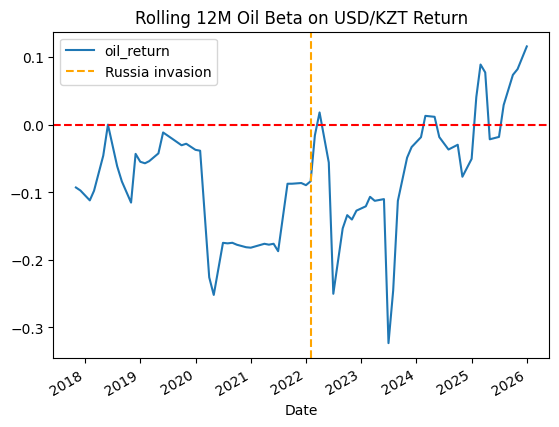

In [ ]:
df_indexed = df.set_index("Date").dropna(subset=["oil_return", "fx_return"])

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

X = sm.add_constant(df_indexed["oil_return"])
y = df_indexed["fx_return"]

rolling_model = RollingOLS(y, X, window=12).fit()
rolling_params = rolling_model.params["oil_return"]

# index is actual dates
rolling_params.plot(title="Rolling 12M Oil Beta on USD/KZT Return")
plt.axhline(0, color="red", linestyle="--")
plt.axvline(pd.Timestamp("2022-02-01"), color="orange", linestyle="--", label="Russia invasion")
plt.legend()
plt.show()

In [46]:
# Remove the broken import, just keep this:
import statsmodels.api as sm

pre  = df[df["Date"] < "2022-02-01"].dropna(subset=["oil_return", "fx_return"])
post = df[df["Date"] >= "2022-02-01"].dropna(subset=["oil_return", "fx_return"])

for label, subset in [("Pre-2022", pre), ("Post-2022", post)]:
    X = sm.add_constant(subset["oil_return"])
    y = subset["fx_return"]
    res = sm.OLS(y, X).fit()
    print(f"\n{label} (n={len(subset)}): oil beta = {res.params['oil_return']:.3f}, "
          f"p-value = {res.pvalues['oil_return']:.3f}, R² = {res.rsquared:.3f}")


Pre-2022 (n=48): oil beta = -0.148, p-value = 0.000, R² = 0.466

Post-2022 (n=34): oil beta = -0.036, p-value = 0.726, R² = 0.004


Pre-2022, oil explained nearly half of all KZT monthly moves, with a highly significant negative relationship. Post-2022, oil explains essentially nothing — the beta is statistically indistinguishable from zero and R² collapses to near-zero. 

The rolling beta chart confirms it visually — the beta was reliably negative from 2018–2022, then after the invasion it oscillates around zero and even turns positive by 2025–2026. The relationship didn't just weaken, it disappeared.

What is driving KZT post-2022 if not oil? 